In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

2026-03-08 13:08:04.225087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772975284.442604      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772975284.502539      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772975284.989690      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772975284.989741      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772975284.989745      17 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/datasets/husseinghandour/dl-training-cnn/train.csv')

x = df.drop('label', axis=1)
y= df['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [3]:
x_train = x_train.to_numpy()
x_test = x_test.to_numpy()
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1))
])

model.add(layers.Conv2D(32, (3,3), use_bias=False))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()

2026-03-08 13:08:32.706861: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,130 (879.41 KB)

 Trainable params: 225,066 (879.16 KB)

 Non-trainable params: 64 (256.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
model.fit(
    x_train,
    y_train,
    epochs= 5,
    validation_split=0.1
)

Epoch 1/5
945/945 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8927 - loss: 0.3335 - val_accuracy: 0.9795 - val_loss: 0.0656
Epoch 2/5
945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9822 - loss: 0.0560 - val_accuracy: 0.9842 - val_loss: 0.0487
Epoch 3/5
945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9889 - loss: 0.0329 - val_accuracy: 0.9821 - val_loss: 0.0612
Epoch 4/5
945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9925 - loss: 0.0241 - val_accuracy: 0.9815 - val_loss: 0.0843
Epoch 5/5
945/945 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9929 - loss: 0.0199 - val_accuracy: 0.9854 - val_loss: 0.0646


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test) 
print(test_acc)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9882 - loss: 0.0443
0.9870238304138184


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
8


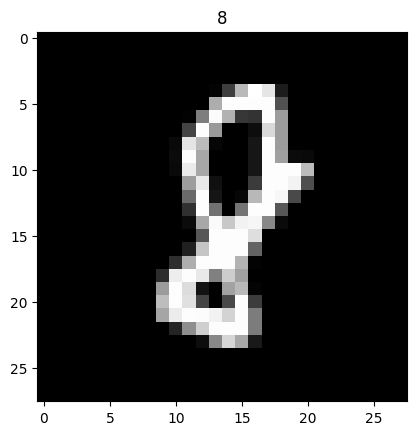

In [8]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()
predictions = model.predict(x_test) 
print(np.argmax(predictions[0])) 
plt.imshow(np.squeeze(x_test[0]), cmap='gray') 
plt.title(y_test[0]) 
plt.show()